# U23AI035 - Assignment 1 - ABBS

In [20]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [4]:
df = pd.read_csv('biomet_data.csv')
print("Shape:", df.shape)
print("Columns:", df.columns[:5], "...", df.columns[-5:])
print("First few rows:")
print(df.head(2))

Shape: (143, 1)
Columns: Index(['  3.0702177e+002\t  2.9677448e+002\t  2.1303365e+002\t  1.9524468e+002\t  2.2944699e+002\t  2.4984867e+002\t  2.9353549e+002\t  1.7068021e+002\t  2.7623258e+002\t  2.8947556e+002\t  1.4883281e+002\t  1.8718627e+002\t  1.6768083e+002\t  1.6659900e+002\t  1.3795955e+002\t  1.6962742e+002\t  1.7474043e+002\t  1.7440039e+002\t  1.6010976e+002\t  1.7225106e+002\t  1.6832723e+002\t  1.8553154e+002\t  1.9944925e+002\t  1.8690129e+002\t  2.3264480e+002\t  1.4629863e+002\t  2.0267909e+002\t  2.4586073e+002\t  1.4291497e+002\t  2.2251461e+002\t  1.5429688e+002\t  1.6494553e+002\t  1.2760982e+002\t  1.9628125e+002\t  1.3909349e+002\t  1.4249522e+002\t  1.9279577e+002\t  2.0847873e+002\t  2.1700679e+002\t  9.9330035e+001\t  2.0666330e+002\t  1.9743132e+002\t  2.1480987e+002\t  1.7657400e+002\t  2.0081614e+002\t  1.3506989e+002\t  1.8708408e+002\t  1.6728091e+002\t  1.6332968e+002\t  1.8563935e+002\t  1.4647650e+002\t  1.3574356e+002\t  1.5339540e+002\t  1.3615326e+

In [5]:
with open('biomet_data.csv', 'r') as f:
    lines = f.readlines()
print("Number of lines:", len(lines))
if len(lines) > 0:
    print("First line snippet:", lines[0][:200])
    print("Comma count in first line:", lines[0].count(','))
    print("Tab count in first line:", lines[0].count('\t'))

Number of lines: 144
First line snippet:   3.0702177e+002	  2.9677448e+002	  2.1303365e+002	  1.9524468e+002	  2.2944699e+002	  2.4984867e+002	  2.9353549e+002	  1.7068021e+002	  2.7623258e+002	  2.8947556e+002	  1.4883281e+002	  1.8718627e+
Comma count in first line: 0
Tab count in first line: 1000


In [8]:
# Load data properly
data = []
with open('biomet_data.csv', 'r') as f:
    for line in f:
        # split by tab, ignore empty strings
        row = [float(x) for x in line.strip().split('\t') if x]
        data.append(row)

In [9]:
data = np.array(data)
print("Original shape (features, samples):", data.shape)

Original shape (features, samples): (144, 1000)


In [10]:
# We want samples x features, so transpose
data = data.T
print("Transposed shape (samples, features):", data.shape)

Transposed shape (samples, features): (1000, 144)


In [ ]:
# create the matching logic
# 100 users, 10 images each (first 5 enrollment, last 5 test)
num_users = 100
images_per_user = 10
enroll_images = 5
test_images = 5

In [13]:
enrollment_data = []
test_data = []
for i in range(num_users):
    user_samples = data[i*images_per_user : (i+1)*images_per_user]
    enrollment_data.append(user_samples[:enroll_images])
    test_data.append(user_samples[enroll_images:])

In [14]:
enrollment_data = np.array(enrollment_data) # (100, 5, 144)
test_data = np.array(test_data) # (100, 5, 144)

In [15]:
# Create templates (average of 5 enrollment images)
templates = np.mean(enrollment_data, axis=1) # (100, 144)
print("Templates shape:", templates.shape)

Templates shape: (100, 144)


In [16]:
# We need to compare every test sample (100 * 5 = 500) against all 100 templates.
# Compute Euclidean distance and Cosine similarity
test_samples = test_data.reshape(-1, 144) # (500, 144)
# Note: test_samples are ordered: User 0 (5 samples), User 1 (5 samples), ..., User 99 (5 samples)

In [17]:
# Euclidean Distance (smaller is better)
euclidean_dists = cdist(test_samples, templates, metric='euclidean') # (500, 100)

In [18]:
# Cosine Distance (smaller is better) -> 1 - Cosine Similarity
cosine_dists = cdist(test_samples, templates, metric='cosine') # (500, 100)
cosine_sims = 1 - cosine_dists # (500, 100), larger is better

In [19]:
print("Euclidean shape:", euclidean_dists.shape)
print("Cosine Sim shape:", cosine_sims.shape)

Euclidean shape: (500, 100)
Cosine Sim shape: (500, 100)


In [21]:
# Ground truth matching
# Each of the 500 test samples has exactly one genuine template and 99 impostor templates
genuine_euclidean = []
impostor_euclidean = []
genuine_cosine = []
impostor_cosine = []

for i in range(500):
    user_id = i // 5
    for j in range(100):
        if j == user_id:
            genuine_euclidean.append(euclidean_dists[i, j])
            genuine_cosine.append(cosine_sims[i, j])
        else:
            impostor_euclidean.append(euclidean_dists[i, j])
            impostor_cosine.append(cosine_sims[i, j])

In [22]:
genuine_euclidean = np.array(genuine_euclidean)
impostor_euclidean = np.array(impostor_euclidean)
genuine_cosine = np.array(genuine_cosine)
impostor_cosine = np.array(impostor_cosine)

In [23]:
print(f"Genuine samples: {len(genuine_euclidean)}, Impostor samples: {len(impostor_euclidean)}")

Genuine samples: 500, Impostor samples: 49500


In [24]:
def compute_eer(fpr, tpr, thresholds):
    fnr = 1 - tpr
    # Find the threshold where FAR (fpr) and FRR (fnr) are closest
    diff = np.abs(fpr - fnr)
    idx = np.argmin(diff)
    eer = (fpr[idx] + fnr[idx]) / 2
    return eer, thresholds[idx]

In [25]:
def decidability_index(gen, imp):
    mu_g, mu_i = np.mean(gen), np.mean(imp)
    var_g, var_i = np.var(gen), np.var(imp)
    d_prime = np.abs(mu_g - mu_i) / np.sqrt((var_g + var_i) / 2)
    return d_prime

In [26]:
# --- EUCLIDEAN DISTANCE ---
# Note: For distance, lower is better. 
# So, score = -distance to use standard ROC functions where higher score = more likely genuine
labels_euc = np.array([1]*len(genuine_euclidean) + [0]*len(impostor_euclidean))
scores_euc = np.concatenate([-genuine_euclidean, -impostor_euclidean])
fpr_euc, tpr_euc, thresh_euc_neg = roc_curve(labels_euc, scores_euc)
fnr_euc = 1 - tpr_euc
thresh_euc = -thresh_euc_neg  # Convert back to positive distances

eer_euc, _ = compute_eer(fpr_euc, tpr_euc, thresh_euc_neg)
d_prime_euc = decidability_index(genuine_euclidean, impostor_euclidean)

In [27]:
# --- COSINE SIMILARITY ---
# For similarity, higher is better.
labels_cos = np.array([1]*len(genuine_cosine) + [0]*len(impostor_cosine))
scores_cos = np.concatenate([genuine_cosine, impostor_cosine])
fpr_cos, tpr_cos, thresh_cos = roc_curve(labels_cos, scores_cos)
fnr_cos = 1 - tpr_cos

eer_cos, _ = compute_eer(fpr_cos, tpr_cos, thresh_cos)
d_prime_cos = decidability_index(genuine_cosine, impostor_cosine)

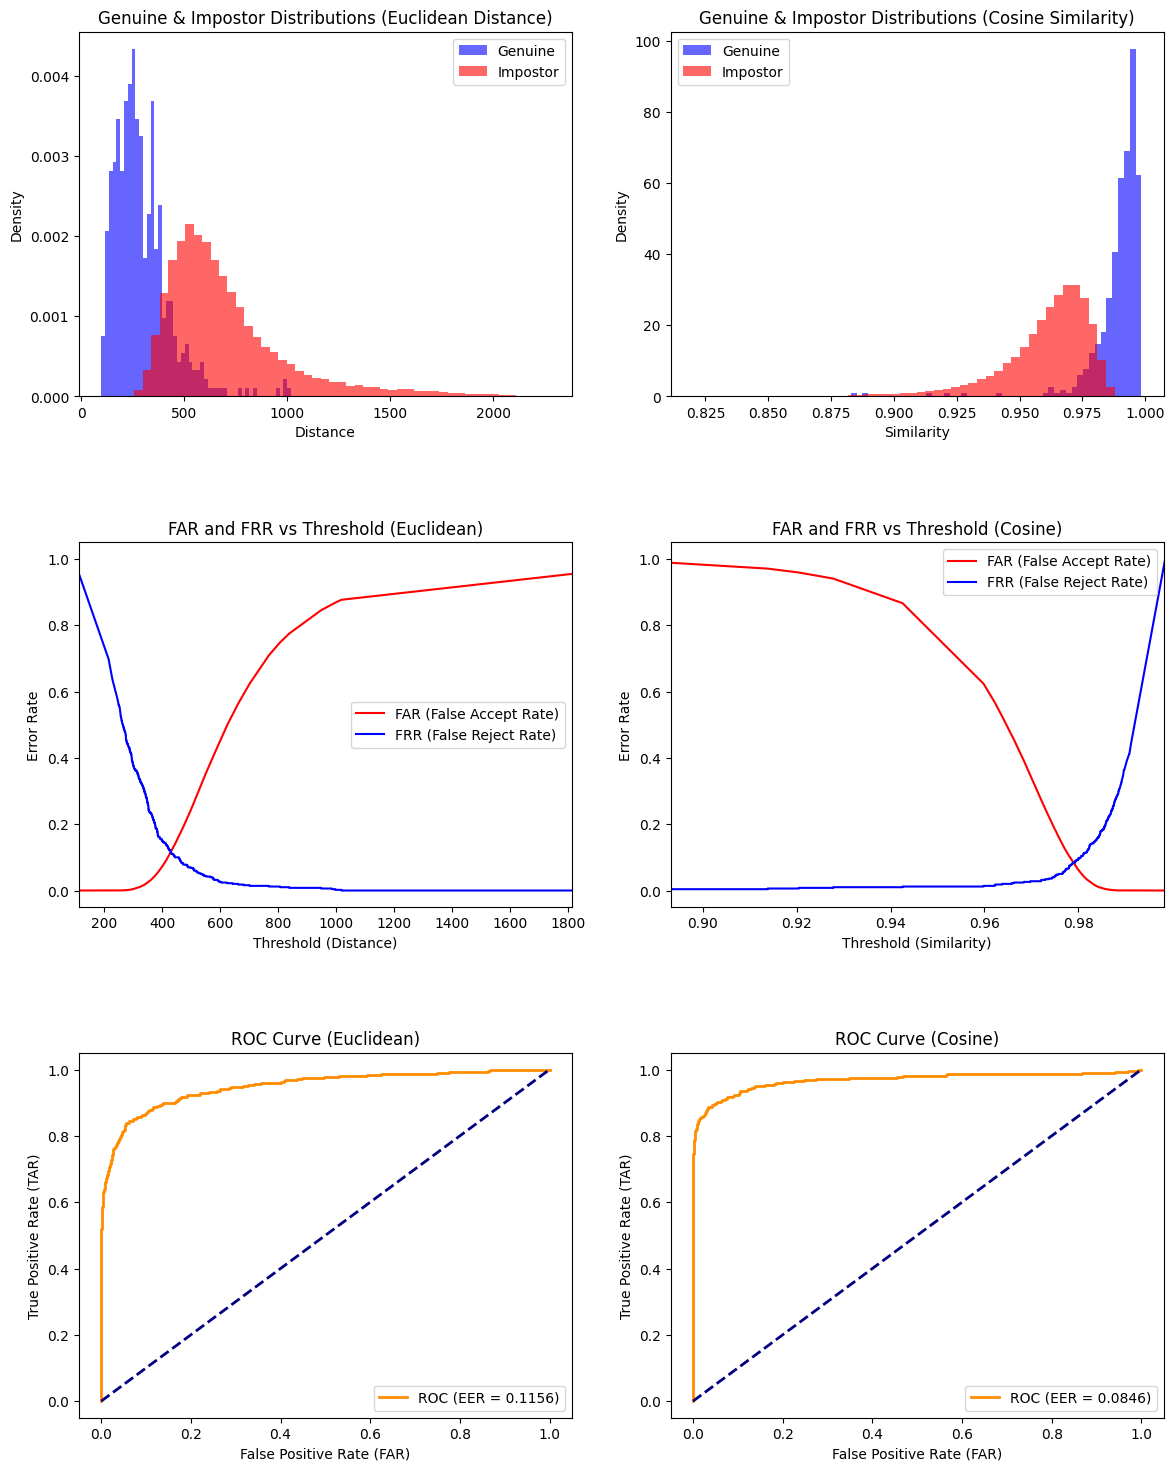

In [28]:
# Plots
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
plt.subplots_adjust(hspace=0.4)

# A & B: Distributions (Euclidean)
axes[0,0].hist(genuine_euclidean, bins=50, alpha=0.6, label='Genuine', density=True, color='blue')
axes[0,0].hist(impostor_euclidean, bins=50, alpha=0.6, label='Impostor', density=True, color='red')
axes[0,0].set_title('Genuine & Impostor Distributions (Euclidean Distance)')
axes[0,0].set_xlabel('Distance')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# A & B: Distributions (Cosine)
axes[0,1].hist(genuine_cosine, bins=50, alpha=0.6, label='Genuine', density=True, color='blue')
axes[0,1].hist(impostor_cosine, bins=50, alpha=0.6, label='Impostor', density=True, color='red')
axes[0,1].set_title('Genuine & Impostor Distributions (Cosine Similarity)')
axes[0,1].set_xlabel('Similarity')
axes[0,1].set_ylabel('Density')
axes[0,1].legend()

# C & D: FAR and FRR Plot (Euclidean)
axes[1,0].plot(thresh_euc, fpr_euc, label='FAR (False Accept Rate)', color='red')
axes[1,0].plot(thresh_euc, fnr_euc, label='FRR (False Reject Rate)', color='blue')
axes[1,0].set_title('FAR and FRR vs Threshold (Euclidean)')
axes[1,0].set_xlabel('Threshold (Distance)')
axes[1,0].set_ylabel('Error Rate')
# limit x axis to meaningful ranges
axes[1,0].set_xlim(np.percentile(genuine_euclidean, 1), np.percentile(impostor_euclidean, 99))
axes[1,0].legend()

# C & D: FAR and FRR Plot (Cosine)
axes[1,1].plot(thresh_cos, fpr_cos, label='FAR (False Accept Rate)', color='red')
axes[1,1].plot(thresh_cos, fnr_cos, label='FRR (False Reject Rate)', color='blue')
axes[1,1].set_title('FAR and FRR vs Threshold (Cosine)')
axes[1,1].set_xlabel('Threshold (Similarity)')
axes[1,1].set_ylabel('Error Rate')
axes[1,1].set_xlim(np.percentile(impostor_cosine, 1), np.percentile(genuine_cosine, 99))
axes[1,1].legend()

# E: ROC Curve (Euclidean)
axes[2,0].plot(fpr_euc, tpr_euc, color='darkorange', lw=2, label=f'ROC (EER = {eer_euc:.4f})')
axes[2,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2,0].set_title('ROC Curve (Euclidean)')
axes[2,0].set_xlabel('False Positive Rate (FAR)')
axes[2,0].set_ylabel('True Positive Rate (TAR)')
axes[2,0].legend(loc="lower right")

# E: ROC Curve (Cosine)
axes[2,1].plot(fpr_cos, tpr_cos, color='darkorange', lw=2, label=f'ROC (EER = {eer_cos:.4f})')
axes[2,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2,1].set_title('ROC Curve (Cosine)')
axes[2,1].set_xlabel('False Positive Rate (FAR)')
axes[2,1].set_ylabel('True Positive Rate (TAR)')
axes[2,1].legend(loc="lower right")

In [29]:
plt.savefig("biometrics_evaluation.png", dpi=300)
plt.close()

In [30]:
print(f"Euclidean - EER: {eer_euc:.4f}, Decidability Index (d'): {d_prime_euc:.4f}")
print(f"Cosine - EER: {eer_cos:.4f}, Decidability Index (d'): {d_prime_cos:.4f}")

Euclidean - EER: 0.1156, Decidability Index (d'): 1.7622
Cosine - EER: 0.0846, Decidability Index (d'): 1.9259
